# Step 6: Model Evaluation — ROC and Precision-Recall Curves

Evaluates out-of-sample predictions from the rolling cross-validation.
Produces ROC curves and precision-recall curves for both incidence and onset targets.
Adapted from Ben Seimon's `exploring_performance_inc.ipynb` and `exploring_performance_ons.ipynb`.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix
)
from pathlib import Path

OUTPUT_DIR  = Path("outputs/figures")
DIAG_DIR    = Path("outputs/diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DIAG_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Load predictions

In [6]:
inc = pd.read_csv("data/processed/gtd_preds_inc.csv", index_col=[0, 1])
ons = pd.read_csv("data/processed/gtd_preds_ons.csv", index_col=[0, 1])

print("Incidence predictions:")
print(inc.head())
print(f"Shape: {inc.shape}")
print(f"Columns: {inc.columns.tolist()}")
print()
print("Onset predictions:")
print(ons.head())
print(f"Shape: {ons.shape}")
print(f"Columns: {ons.columns.tolist()}")

Incidence predictions:
             inc_target  n_attacks_strict_since_0  preds_inc
iso3 period                                                 
AFG  201901         1.0                         0   0.974337
     201902         1.0                         0   0.973586
     201903         1.0                         0   0.975117
     201904         1.0                         0   0.971662
     201905         1.0                         0   0.976325
Shape: (3744, 3)
Columns: ['inc_target', 'n_attacks_strict_since_0', 'preds_inc']

Onset predictions:
             ons_target  n_attacks_strict_since_0  preds_ons
iso3 period                                                 
AFG  201901         NaN                         0   0.809796
     201902         NaN                         0   0.805782
     201903         NaN                         0   0.800017
     201904         NaN                         0   0.791473
     201905         NaN                         0   0.808560
Shape: (3744, 3)
Colu

In [7]:
# Identify the target and prediction columns
# The target column is the one that is 0/1, the pred column ends in _preds or similar
inc_target_col = "inc_target"
inc_pred_col   = "preds_inc"
ons_target_col = "ons_target"
ons_pred_col   = "preds_ons"

# Drop rows where target is missing
inc_clean = inc.dropna(subset=[inc_target_col, inc_pred_col]).copy()
ons_clean = ons.dropna(subset=[ons_target_col, ons_pred_col]).copy()

print(f"Incidence: {len(inc_clean):,} valid prediction rows")
print(f"  Positive rate: {inc_clean[inc_target_col].mean():.1%}")
print()
print(f"Onset: {len(ons_clean):,} valid prediction rows")
print(f"  Positive rate: {ons_clean[ons_target_col].mean():.1%}")

Incidence: 3,588 valid prediction rows
  Positive rate: 28.8%

Onset: 2,324 valid prediction rows
  Positive rate: 20.6%


## 2. Compute curves

In [8]:
# ── ROC curves ──────────────────────────────────────────────────────────────
fpr_inc, tpr_inc, _ = roc_curve(inc_clean[inc_target_col], inc_clean[inc_pred_col])
auc_inc = auc(fpr_inc, tpr_inc)

fpr_ons, tpr_ons, _ = roc_curve(ons_clean[ons_target_col], ons_clean[ons_pred_col])
auc_ons = auc(fpr_ons, tpr_ons)

# ── Precision-Recall curves ──────────────────────────────────────────────────
prec_inc, rec_inc, _ = precision_recall_curve(inc_clean[inc_target_col], inc_clean[inc_pred_col])
ap_inc = average_precision_score(inc_clean[inc_target_col], inc_clean[inc_pred_col])

prec_ons, rec_ons, _ = precision_recall_curve(ons_clean[ons_target_col], ons_clean[ons_pred_col])
ap_ons = average_precision_score(ons_clean[ons_target_col], ons_clean[ons_pred_col])

# Baseline (random classifier)
baseline_inc = inc_clean[inc_target_col].mean()
baseline_ons = ons_clean[ons_target_col].mean()

print(f"Incidence — AUC-ROC: {auc_inc:.3f} | Average Precision: {ap_inc:.3f} | Baseline: {baseline_inc:.3f}")
print(f"Onset     — AUC-ROC: {auc_ons:.3f} | Average Precision: {ap_ons:.3f} | Baseline: {baseline_ons:.3f}")

Incidence — AUC-ROC: 0.939 | Average Precision: 0.893 | Baseline: 0.288
Onset     — AUC-ROC: 0.843 | Average Precision: 0.655 | Baseline: 0.206


## 3. Plot ROC and Precision-Recall curves

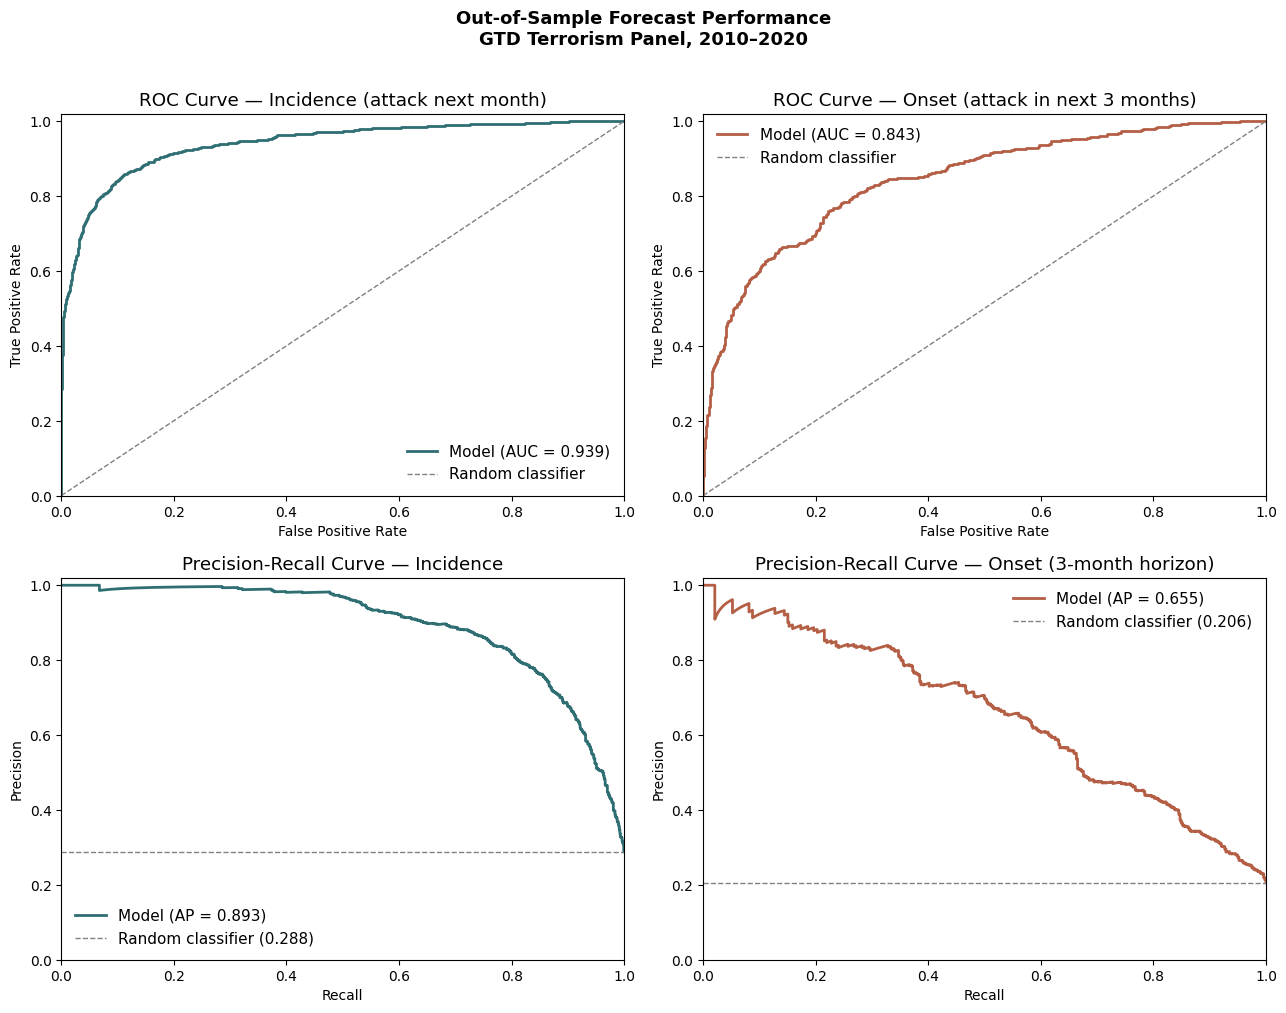

Saved: outputs/figures/roc_pr_curves.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

color_inc = "#2f6f73"
color_ons = "#b45f45"

# ── Incidence ROC ────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(fpr_inc, tpr_inc, color=color_inc, lw=2, label=f"Model (AUC = {auc_inc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Incidence (attack next month)")
ax.legend(frameon=False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Onset ROC ────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(fpr_ons, tpr_ons, color=color_ons, lw=2, label=f"Model (AUC = {auc_ons:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Onset (attack in next 3 months)")
ax.legend(frameon=False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Incidence PR ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(rec_inc, prec_inc, color=color_inc, lw=2, label=f"Model (AP = {ap_inc:.3f})")
ax.axhline(y=baseline_inc, color="gray", linestyle="--", lw=1,
           label=f"Random classifier ({baseline_inc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Incidence")
ax.legend(frameon=False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Onset PR ──────────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(rec_ons, prec_ons, color=color_ons, lw=2, label=f"Model (AP = {ap_ons:.3f})")
ax.axhline(y=baseline_ons, color="gray", linestyle="--", lw=1,
           label=f"Random classifier ({baseline_ons:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Onset (3-month horizon)")
ax.legend(frameon=False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.suptitle("Out-of-Sample Forecast Performance\nGTD Terrorism Panel, 2010–2020",
             fontsize=13, fontweight="semibold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/figures/roc_pr_curves.png")

## 4. Performance summary table

In [10]:
summary = pd.DataFrame([
    {
        "Target": "Incidence (next month)",
        "Valid rows": len(inc_clean),
        "Positive rate": f"{baseline_inc:.3f}",
        "AUC-ROC": f"{auc_inc:.3f}",
        "Average Precision": f"{ap_inc:.3f}",
        "Skill vs random (AP)": f"{ap_inc / baseline_inc:.2f}x",
    },
    {
        "Target": "Onset (next 3 months)",
        "Valid rows": len(ons_clean),
        "Positive rate": f"{baseline_ons:.3f}",
        "AUC-ROC": f"{auc_ons:.3f}",
        "Average Precision": f"{ap_ons:.3f}",
        "Skill vs random (AP)": f"{ap_ons / baseline_ons:.2f}x",
    },
])

print("=== Performance Summary ===")
print(summary.to_string(index=False))
summary.to_csv(DIAG_DIR / "performance_summary.csv", index=False)

=== Performance Summary ===
                Target  Valid rows Positive rate AUC-ROC Average Precision Skill vs random (AP)
Incidence (next month)        3588         0.288   0.939             0.893                3.10x
 Onset (next 3 months)        2324         0.206   0.843             0.655                3.18x


## 5. Prediction score distributions

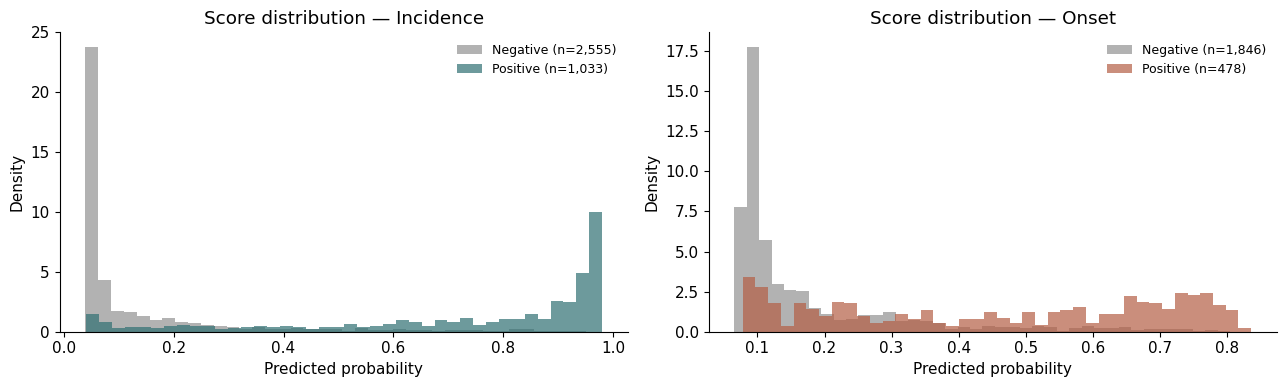

Saved: outputs/figures/score_distributions.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, pred_col, target_col, title, color in [
    (axes[0], inc_clean, inc_pred_col, inc_target_col, "Incidence", color_inc),
    (axes[1], ons_clean, ons_pred_col, ons_target_col, "Onset",     color_ons),
]:
    pos = df.loc[df[target_col] == 1, pred_col]
    neg = df.loc[df[target_col] == 0, pred_col]
    ax.hist(neg, bins=40, alpha=0.6, color="gray",  label=f"Negative (n={len(neg):,})", density=True)
    ax.hist(pos, bins=40, alpha=0.7, color=color,   label=f"Positive (n={len(pos):,})", density=True)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.set_title(f"Score distribution — {title}")
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "score_distributions.png", dpi=200)
plt.show()
print("Saved: outputs/figures/score_distributions.png")

## 6. BONUS — Cost model and optimal cutoff

Following Session 4 from the course. We define costs for TP, FP, TN, FN and find
the optimal decision threshold using the isocost line on the ROC curve.

**Decision-maker:** an international early warning body (e.g. UN, INTERPOL regional office)
deciding whether to pre-position prevention resources in a country-month.

**Cost assumptions:**
- **FN (miss a real onset):** very high — failing to prevent an attack has human and political costs
- **FP (false alarm):** lower but non-trivial — deploying resources unnecessarily wastes budget
- **TP:** benefit (prevention); **TN:** correct non-deployment (saves budget)

We set cost_FN = 10, cost_FP = 1 (ratio reflects asymmetry in harm).

=== Cost Model: Onset ===
  cost_FN=10, cost_FP=1
  Prevalence: 0.206
  Isocost slope: 0.3862
  Optimal threshold: 0.106
  At optimal threshold:
    TPR (sensitivity): 0.910
    FPR:               0.497
    TP=435, FP=917, TN=929, FN=43
    Precision: 0.322


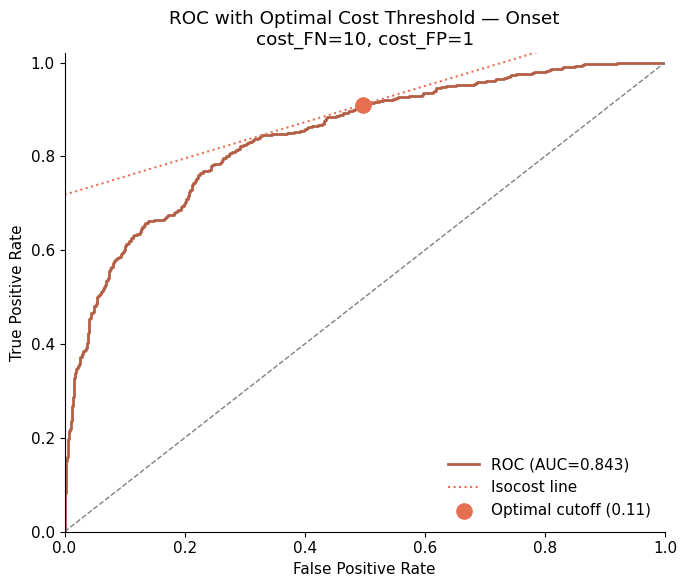

Saved: outputs/figures/roc_cost_model_onset.png


In [12]:
cost_FN = 10  # cost of missing a real onset
cost_FP = 1   # cost of a false alarm

# Optimal threshold: minimise expected cost = cost_FN * FNR + cost_FP * FPR
# On ROC curve: isocost slope = cost_FP / cost_FN * (1 - prevalence) / prevalence
# Optimal point: maximise TPR - (cost_FP/cost_FN) * FPR

for label, df, pred_col, target_col, fpr, tpr, thresholds_roc in [
    ("Onset", ons_clean, ons_pred_col, ons_target_col,
     fpr_ons, tpr_ons,
     roc_curve(ons_clean[ons_target_col], ons_clean[ons_pred_col])[2]),
]:
    prevalence = df[target_col].mean()
    slope = (cost_FP / cost_FN) * ((1 - prevalence) / prevalence)

    # Score each threshold point on the ROC curve
    scores = tpr - slope * fpr
    best_idx = np.argmax(scores)
    best_threshold = thresholds_roc[best_idx]
    best_tpr = tpr[best_idx]
    best_fpr = fpr[best_idx]

    # Confusion matrix at optimal threshold
    y_pred = (df[pred_col] >= best_threshold).astype(int)
    cm = confusion_matrix(df[target_col], y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"=== Cost Model: {label} ===")
    print(f"  cost_FN={cost_FN}, cost_FP={cost_FP}")
    print(f"  Prevalence: {prevalence:.3f}")
    print(f"  Isocost slope: {slope:.4f}")
    print(f"  Optimal threshold: {best_threshold:.3f}")
    print(f"  At optimal threshold:")
    print(f"    TPR (sensitivity): {best_tpr:.3f}")
    print(f"    FPR:               {best_fpr:.3f}")
    print(f"    TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"    Precision: {tp/(tp+fp):.3f}" if (tp+fp) > 0 else "    Precision: N/A")

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color=color_ons, lw=2, label=f"ROC (AUC={auc_ons:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)

    # Draw isocost line through optimal point
    x_iso = np.linspace(0, 1, 100)
    y_iso = best_tpr + slope * (x_iso - best_fpr)
    ax.plot(x_iso, y_iso, ":", color="#e76f51", lw=1.5, label="Isocost line")
    ax.scatter([best_fpr], [best_tpr], color="#e76f51", s=120, zorder=5,
               label=f"Optimal cutoff ({best_threshold:.2f})")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC with Optimal Cost Threshold — {label}\n"
                 f"cost_FN={cost_FN}, cost_FP={cost_FP}")
    ax.legend(frameon=False)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"roc_cost_model_{label.lower()}.png", dpi=200)
    plt.show()
    print(f"Saved: outputs/figures/roc_cost_model_{label.lower()}.png")

## 7. Interpret the curves

Fill in after running — use these numbers for the Results section of the writeup.

In [13]:
print("=== Key numbers for the writeup ===")
print(f"Incidence AUC-ROC:        {auc_inc:.3f}")
print(f"Onset AUC-ROC:            {auc_ons:.3f}")
print(f"Incidence Avg Precision:  {ap_inc:.3f}  (baseline {baseline_inc:.3f}, "
      f"skill {ap_inc/baseline_inc:.1f}x)")
print(f"Onset Avg Precision:      {ap_ons:.3f}  (baseline {baseline_ons:.3f}, "
      f"skill {ap_ons/baseline_ons:.1f}x)")
print()
print("Interpretation guidance:")
print("  AUC > 0.7: reasonable discrimination")
print("  AUC > 0.8: good discrimination")
print("  Onset AUC < Incidence AUC: expected — onset is the harder problem")
print("  Skill ratio > 2x: model substantially beats random on PR curve")
print("  PR curve more informative than ROC for imbalanced classes")

=== Key numbers for the writeup ===
Incidence AUC-ROC:        0.939
Onset AUC-ROC:            0.843
Incidence Avg Precision:  0.893  (baseline 0.288, skill 3.1x)
Onset Avg Precision:      0.655  (baseline 0.206, skill 3.2x)

Interpretation guidance:
  AUC > 0.7: reasonable discrimination
  AUC > 0.8: good discrimination
  Onset AUC < Incidence AUC: expected — onset is the harder problem
  Skill ratio > 2x: model substantially beats random on PR curve
  PR curve more informative than ROC for imbalanced classes
